In [1]:
from Attention import LSTM, Layer_Dense, Attention
import numpy as np

np.random.seed(0)

# ----------------------------
# Toy "machine translation" data:
# map sequences of length L over vocab {1..V-2} to reversed sequence
# with <SOS>=0, <EOS>=V-1
# ----------------------------

V = 8  # vocab size
SOS = 0
EOS = V - 1
max_len = 5
n_samples = 1000

In [2]:
def generate_sample():
    length = np.random.randint(1, max_len + 1)
    # tokens in 1..V-2
    src_seq = np.random.randint(1, V - 1, size=length)
    # target is reversed source
    tgt_seq = src_seq[::-1]
    # add EOS
    tgt_seq = np.concatenate([tgt_seq, [EOS]])
    return src_seq, tgt_seq

In [3]:
def one_hot_sequence(seq, T):
    # seq: array of token ids (int)
    # T: fixed time length (pad with EOS)
    x = np.zeros((T, V))
    for t in range(len(seq)):
        x[t, seq[t]] = 1.0
    for t in range(len(seq), T):
        x[t, EOS] = 1.0
    return x

In [4]:
# build dataset
T_enc = max_len
T_dec = max_len + 1  # reversed plus EOS
X_enc = []
X_dec_in = []
Y_dec = []

for _ in range(n_samples):
    src, tgt = generate_sample()

    # encoder input: src, padded
    X_enc.append(one_hot_sequence(src, T_enc))

    # decoder input: [SOS] + tgt[:-1]
    dec_in = np.concatenate([[SOS], tgt[:-1]])
    X_dec_in.append(one_hot_sequence(dec_in, T_dec))

    # decoder output (targets): tgt, padded to T_dec
    y = np.full(T_dec, EOS, dtype=int)
    y[:len(tgt)] = tgt
    Y_dec.append(y)

In [5]:
X_enc = np.array(X_enc)  # (N, T_enc, V)
X_dec_in = np.array(X_dec_in)  # (N, T_dec, V)
Y_dec = np.array(Y_dec)  # (N, T_dec)

# ----------------------------
# Model: encoder LSTM + decoder LSTM + output dense
# ----------------------------

In [6]:
n_neurons = 64

encoder = LSTM(n_neurons, input_dim=V)
decoder = LSTM(n_neurons, input_dim=V)

In [7]:
encoder.dUf.fill(0.0)

#### Decoder output: from h_t^dec (size n_neurons) -> vocab logits (size V)
#### We'll operate per time-step, so we can have a single dense over n_neurons -> V
#### but we can also flatten time dimension; for clarity we'll process all times at once.

In [8]:
hidden_size = encoder.n_neurons
output_layer = Layer_Dense(hidden_size * 2, V)

attention = Attention(hidden_size)
lr = 1e-2
n_epochs = 50
batch_size = 32

In [9]:
def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    exp = np.exp(x)
    return exp / np.sum(exp, axis=-1, keepdims=True)

In [11]:
for epoch in range(n_epochs):
    perm = np.random.permutation(n_samples)
    X_enc = X_enc[perm]
    X_dec_in = X_dec_in[perm]
    Y_dec = Y_dec[perm]

    total_loss = 0.0

    for start in range(0, n_samples, batch_size):
        end = start + batch_size
        if end > n_samples:
            break

        x_e = X_enc[start:end]  # (B, T_enc, V)
        x_d = X_dec_in[start:end]  # (B, T_dec, V)
        y = Y_dec[start:end]  # (B, T_dec)

        B = x_e.shape[0]

        # Accumulate grads manually across batch (since your LSTM isn't batched)
        # We'll loop over samples in the batch; it's slow but conceptually simple.

        batch_loss = 0.0

        # Zero parameter grads
        # (They will be accumulated across samples and then updated once)
        # Encoder
        encoder.dUf.fill(0.0)
        encoder.dUi.fill(0.0);
        encoder.dUo.fill(0.0);
        encoder.dUg.fill(0.0)
        encoder.dWf.fill(0.0);
        encoder.dWi.fill(0.0);
        encoder.dWo.fill(0.0);
        encoder.dWg.fill(0.0)
        encoder.dbf.fill(0.0);
        encoder.dbi.fill(0.0);
        encoder.dbo.fill(0.0);
        encoder.dbg.fill(0.0)

        # Decoder
        decoder.dUf.fill(0.0);
        decoder.dUi.fill(0.0);
        decoder.dUo.fill(0.0);
        decoder.dUg.fill(0.0)
        decoder.dWf.fill(0.0);
        decoder.dWi.fill(0.0);
        decoder.dWo.fill(0.0);
        decoder.dWg.fill(0.0)
        decoder.dbf.fill(0.0);
        decoder.dbi.fill(0.0);
        decoder.dbo.fill(0.0);
        decoder.dbg.fill(0.0)

        # Output layer
        output_layer.dweights = np.zeros_like(output_layer.weights)
        output_layer.dbiases = np.zeros_like(output_layer.biases)

        for b in range(B):
            # -------- Encoder forward --------
            # shape (T_enc, V) -> list of (V,1) per time
            enc_in = x_e[b]  # (T_enc, V)
            encoder.forward(enc_in)  # h0=c0=0

            # encoder hidden states: H[1:] shape (T_enc, hidden_size, 1)
            H_enc = np.array(encoder.H[1:]).reshape(encoder.T, hidden_size)  # (T_enc, hidden_size)

            h_enc = encoder.H[encoder.T]  # (n_neurons, 1)
            c_enc = encoder.C[encoder.T]  # (n_neurons, 1)

            # -------- Decoder forward --------
            dec_in = x_d[b]  # (T_dec, V)
            decoder.forward(dec_in, h0=h_enc, c0=c_enc)


            H_dec_list = decoder.H[1:]                         # list of (hidden_size,1)
            H_dec = np.array(H_dec_list).reshape(decoder.T, hidden_size)  # (T_dec, hidden_size)

            # -------- Attention + output layer forward --------
            # For each decoder time-step t, compute context c_t and concat with h_dec_t
            combined_list = []
            # Option: use previous decoder state as s_prev for scores. Here we just use current h_dec_t.
            for t in range(decoder.T):
                h_t = H_dec[t].reshape(-1, 1)          # (hidden_size,1)
                # attention.forward expects: H_enc (T_enc, hidden_size), s_prev (hidden_size,)
                c_t, alpha_t = attention.forward(H_enc, h_t.reshape(-1))  # c_t: (hidden_size,)
                combined = np.concatenate([h_t.reshape(-1), c_t])         # (2*hidden_size,)
                combined_list.append(combined)

            combined_arr = np.stack(combined_list, axis=0)  # (T_dec, 2*hidden_size)

            logits = output_layer.forward(combined_arr)     # (T_dec, V)
            probs = softmax(logits)

            # -------- Loss --------
            idx = y[b]                                      # (T_dec,)
            logp = -np.log(probs[np.arange(decoder.T), idx] + 1e-12)
            loss = np.mean(logp)
            batch_loss += loss

            # -------- Backward pass --------
            # Softmax + cross-entropy derivative wrt logits
            dlogits = probs.copy()
            dlogits[np.arange(decoder.T), idx] -= 1.0
            dlogits /= decoder.T  # mean over time

            # Backprop through output dense
            output_layer.backward(dlogits)  # sets dweights, dbiases, dinputs

            # dinputs is gradient w.r.t combined [h_t ; c_t]
            dcombined = output_layer.dinputs  # (T_dec, 2*hidden_size)

            # We split dcombined into parts for h_t (decoder) and c_t (attention)
            dH_dec = dcombined[:, :hidden_size]  # (T_dec, hidden_size)
            # dc_t = dcombined[:, hidden_size:]   # (T_dec, hidden_size)
            # NOTE: We are currently NOT backpropagating dc_t through attention.
            # That would require deriving gradients for W_h, W_s, v and H_enc as well.

            # Backprop through decoder LSTM using only dH_dec
            decoder.backward(dH_dec)

            # -------- Encoder gradient approximate link (same as your original) --------
            dh_enc_T = (decoder.Wf.T @ decoder.Sigmf[0].dinputs +
                        decoder.Wi.T @ decoder.Sigmi[0].dinputs +
                        decoder.Wo.T @ decoder.Sigmo[0].dinputs +
                        decoder.Wg.T @ decoder.Tanh1[0].dinputs)

            dH_enc = np.zeros((encoder.T, encoder.n_neurons))
            dH_enc[-1] = dh_enc_T.reshape(-1)

            encoder.backward(dH_enc)

            # average loss over batch
            batch_loss /= B
            total_loss += batch_loss


        # -------- SGD update after batch --------
        # encoder update
        encoder.Uf -= lr * encoder.dUf
        encoder.Ui -= lr * encoder.dUi
        encoder.Uo -= lr * encoder.dUo
        encoder.Ug -= lr * encoder.dUg

        encoder.Wf -= lr * encoder.dWf
        encoder.Wi -= lr * encoder.dWi
        encoder.Wo -= lr * encoder.dWo
        encoder.Wg -= lr * encoder.dWg

        encoder.bf -= lr * encoder.dbf
        encoder.bi -= lr * encoder.dbi
        encoder.bo -= lr * encoder.dbo
        encoder.bg -= lr * encoder.dbg

        # decoder update
        decoder.Uf -= lr * decoder.dUf
        decoder.Ui -= lr * decoder.dUi
        decoder.Uo -= lr * decoder.dUo
        decoder.Ug -= lr * decoder.dUg

        decoder.Wf -= lr * decoder.dWf
        decoder.Wi -= lr * decoder.dWi
        decoder.Wo -= lr * decoder.dWo
        decoder.Wg -= lr * decoder.dWg

        decoder.bf -= lr * decoder.dbf
        decoder.bi -= lr * decoder.dbi
        decoder.bo -= lr * decoder.dbo
        decoder.bg -= lr * decoder.dbg

        # output dense layer update
        output_layer.weights -= lr * output_layer.dweights
        output_layer.biases -= lr * output_layer.dbiases

    print(f"Epoch {epoch + 1}/{n_epochs}, loss: {total_loss:.4f}")

Epoch 1/50, loss: 29.9668
Epoch 2/50, loss: 29.9182
Epoch 3/50, loss: 29.9482
Epoch 4/50, loss: 29.9169
Epoch 5/50, loss: 29.9434
Epoch 6/50, loss: 29.8955
Epoch 7/50, loss: 29.8416
Epoch 8/50, loss: 29.8914
Epoch 9/50, loss: 29.8311
Epoch 10/50, loss: 29.9056
Epoch 11/50, loss: 29.8364
Epoch 12/50, loss: 29.9143
Epoch 13/50, loss: 30.0273
Epoch 14/50, loss: 29.8083
Epoch 15/50, loss: 31.0871
Epoch 16/50, loss: 29.9290
Epoch 17/50, loss: 30.5458
Epoch 18/50, loss: 30.1287
Epoch 19/50, loss: 30.1134
Epoch 20/50, loss: 31.3872
Epoch 21/50, loss: 29.9048
Epoch 22/50, loss: 29.9905
Epoch 23/50, loss: 30.0610
Epoch 24/50, loss: 30.9268
Epoch 25/50, loss: 30.0930
Epoch 26/50, loss: 30.2129
Epoch 27/50, loss: 30.1512
Epoch 28/50, loss: 30.4053
Epoch 29/50, loss: 30.1627
Epoch 30/50, loss: 30.1174
Epoch 31/50, loss: 31.1381
Epoch 32/50, loss: 30.0547
Epoch 33/50, loss: 30.1651
Epoch 34/50, loss: 30.2047
Epoch 35/50, loss: 30.1597
Epoch 36/50, loss: 30.5013
Epoch 37/50, loss: 29.9907
Epoch 38/5

## Test Mode

In [16]:
def encode_sequence(enc_seq):
    encoder.forward(enc_seq)
    H_enc = np.array(encoder.H[1:]).reshape(encoder.T, hidden_size)
    h_enc = encoder.H[encoder.T]
    c_enc = encoder.C[encoder.T]
    return H_enc, h_enc, c_enc

In [17]:
def decode_sequence(H_enc, h0, c0, max_len=T_dec):
    # greedy decoding
    dec_input = np.zeros((1, V))
    dec_input[0, SOS] = 1.0

    h = h0.copy()
    c = c0.copy()

    generated = []
    attentions = []

    for t in range(max_len):
        # one step decoder: we fake a single-time-step sequence
        decoder.forward(dec_input, h0=h, c0=c)

        h = decoder.H[decoder.T]
        c = decoder.C[decoder.T]
        h_vec = h.reshape(-1, 1)

        # attention context
        c_t, alpha_t = attention.forward(H_enc, h_vec.reshape(-1))
        attentions.append(alpha_t)
        combined = np.concatenate([h_vec.reshape(-1), c_t]).reshape(1, -1)
        logits = output_layer.forward(combined)
        probs = softmax(logits)[0]

        token = np.argmax(probs)
        generated.append(token)

        if token == EOS:
            break

        # next decoder input
        dec_input = np.zeros((1, V))
        dec_input[0, token] = 1.0

    return np.array(generated), np.array(attentions)

In [18]:
def predict(src_seq):
    enc_x = one_hot_sequence(src_seq, T_enc)
    H_enc, h_enc, c_enc = encode_sequence(enc_x)
    pred, att = decode_sequence(H_enc, h_enc, c_enc, max_len=T_dec)
    return pred, att

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def show_attention(src_tokens, pred_tokens, att_matrix):
    plt.figure(figsize=(8, 6))
    plt.imshow(att_matrix, cmap='viridis')

    plt.xlabel("Source tokens")
    plt.ylabel("Generated tokens")

    plt.xticks(ticks=np.arange(len(src_tokens)), labels=src_tokens)
    plt.yticks(ticks=np.arange(len(pred_tokens)), labels=pred_tokens)

    plt.colorbar(label='Attention weight')
    plt.title("Attention Alignment")
    plt.show()

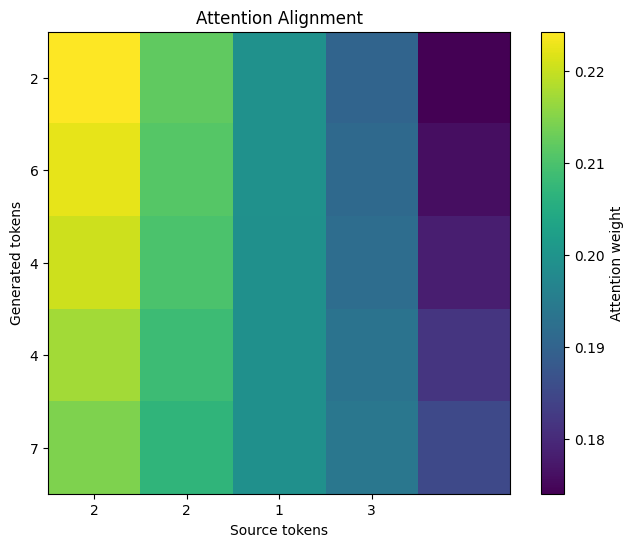

In [21]:
src, tgt = generate_sample()
pred, att = predict(src)

src_tokens = [int(i) for i in src]
pred_tokens = [int(i) for i in pred]

show_attention(src_tokens, pred_tokens, att)

In [15]:
# quick test
for i in range(5):
    src, tgt = generate_sample()
    pred = predict(src)

    print("SRC: ", src)
    print("TGT: ", tgt[:-1])  # remove EOS for display
    print("PRED:", pred)
    print()

SRC:  [4 1 4 1 2]
TGT:  [2 1 4 1 4]
PRED: [2 6 2 4 1 7]

SRC:  [5 1 3]
TGT:  [3 1 5]
PRED: [2 4 7]

SRC:  [3 1]
TGT:  [1 3]
PRED: [4 7]

SRC:  [5 2 3 4]
TGT:  [4 3 2 5]
PRED: [2 6 4 7]

SRC:  [2 6 1 5 4]
TGT:  [4 5 1 6 2]
PRED: [2 6 2 4 1 7]

